**Univariate Time Series Analysis**

A classical + ML-friendly approach that works very well for teaching:

👉 ARIMA (baseline time-series model)

👉 Clear train/test split (time-aware)

👉 Multiple line plots for explanation

👉 Clean, readable, and classroom-ready

You can later extend this to LSTM in your DL Module.

**Import required libraries**

In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

**Reading data** 

In [230]:
df = pd.read_csv("C:/MAFAS/APU/CT046-3-M-AML/CT046 - LABS/Python LAB MATERIALS/Lab 13 - Univariate Time Series Analysis/Stock.csv")
df.head()

,Date,Close
0,28/9/2018,233.75
1,27/9/2018,233.25
2,26/9/2018,234.25
3,25/9/2018,236.10
4,24/9/2018,233.30


**Date Handling**

In [231]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst = True)
df = df.sort_values('Date')
df.set_index('Date', inplace = True)

# Set business-day frequency
df = df.asfreq('B')

# Forward-fill missing prices
df['Close'] = df['Close'].ffill()

print(df.head())
print(df.index.freq)


             Close
Date              
2010-07-21  121.55
2010-07-22  120.90
2010-07-23  120.65
2010-07-26  117.60
2010-07-27  118.65
<BusinessDay>


**Exploratory Data Analysis (EDA)**

Plot Close Price Over Time

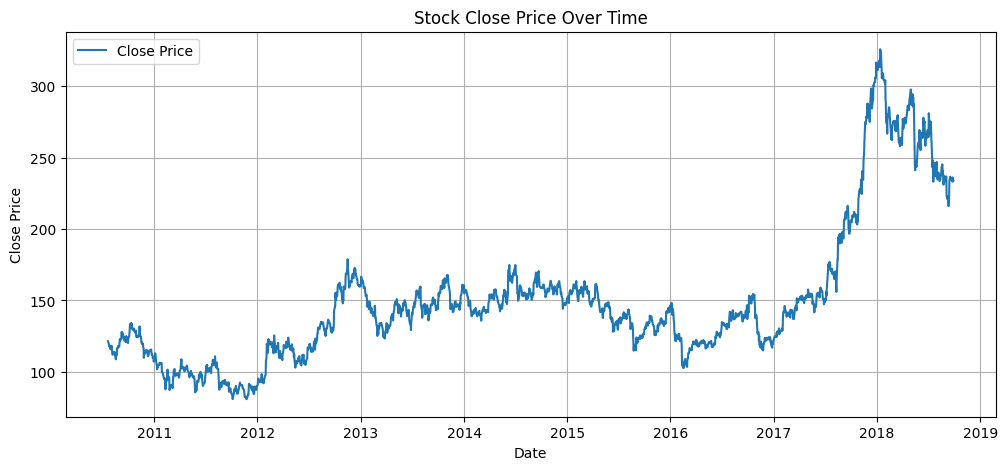

In [232]:
plt.figure(figsize = (12,5))
plt.plot(df.index, df['Close'], label = 'Close Price')
plt.title("Stock Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()


We can understand:

* Trend

* Volatility

* Non-stationarity (important for ARIMA)

**Train–Test Split (Time-Based)**

In [233]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

print("Training size:", train.shape)
print("Testing size:", test.shape)

Training size: (1710, 1)
Testing size: (428, 1)


**Build ARIMA Model**

we’ll start with a simple ARIMA(5,1,0).

📌 Explanation:

* p = 5 → past observations

* d = 1 → differencing

* q = 0 → moving average

In [234]:
model = ARIMA(train['Close'], order = (5,1,0), trend = 't')
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1710
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -4021.505
Date:                Sun, 25 Jan 2026   AIC                           8057.010
Time:                        23:10:18   BIC                           8095.116
Sample:                    07-21-2010   HQIC                          8071.113
                         - 02-07-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0116      0.061      0.190      0.849      -0.108       0.131
ar.L1         -0.0254      0.024     -1.057      0.291      -0.073       0.022
ar.L2          0.0274      0.024      1.164      0.2

**Forecast & Evaluation**

In [235]:
test_forecast = model_fit.forecast(steps = len(test))
test_forecast = pd.Series(test_forecast, index=test.index)

mae = mean_absolute_error(test['Close'], test_forecast)
rmse = np.sqrt(mean_squared_error(test['Close'], test_forecast))

print("MAE :", mae)
print("RMSE:", rmse)


MAE : 79.62771390014429
RMSE: 96.22066387953674


**Plot Train/Test Forecast**

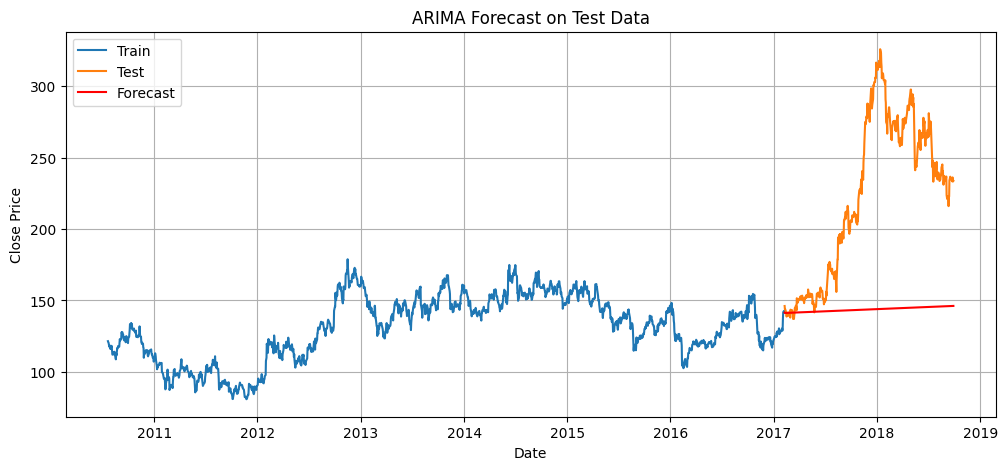

In [236]:
plt.figure(figsize = (12,5))
plt.plot(train.index, train['Close'], label = 'Train')
plt.plot(test.index, test['Close'], label = 'Test')
plt.plot(test_forecast.index, test_forecast, label = 'Forecast', color = 'red')

plt.title("ARIMA Forecast on Test Data")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

**Re-fit the model on FULL data before future forecasting**

In [237]:
final_model = ARIMA(df['Close'], order = (5,1,0), trend = 't')
final_fit = final_model.fit()

**Forecast Next 30 Business Days**

In [238]:
future_steps = 90
future_forecast = final_fit.forecast(steps = future_steps)

future_dates = pd.date_range(
    start = df.index[-1],
    periods = future_steps + 1,
    freq = 'B'
)[1:]

**Final Correct Plot**

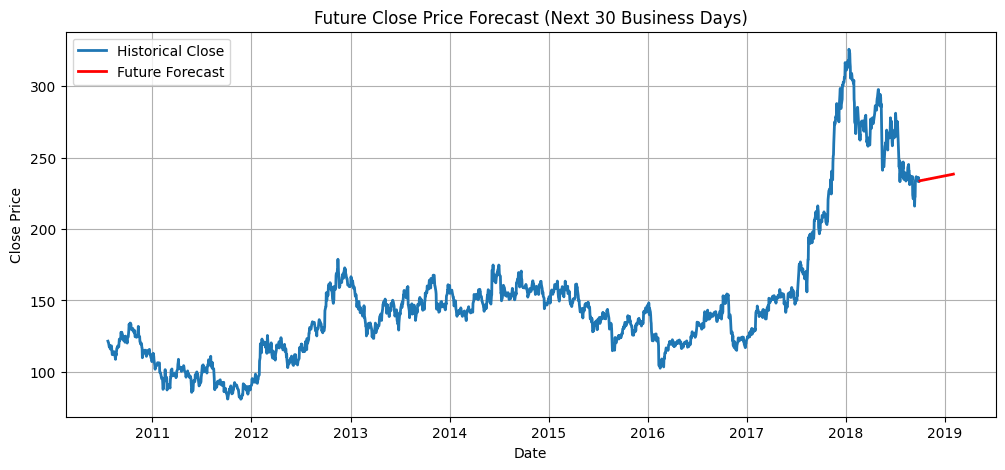

In [ ]:
plt.figure(figsize = (12,5))

plt.plot(df.index, df['Close'], label = 'Historical Close', linewidth = 2)
plt.plot(future_dates, future_forecast, label = 'Future Forecast', color = 'red', linewidth = 2)

plt.title("Future Close Price Forecast (Next 90 Business Days)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

ARIMA(5,1,0) with linear trend is mathematically constrained to produce a smooth drift, and it cannot capture the explosive regime change present in the test period.

**ARIMA is good for:**

✅ Short-term forecasting
✅ Stable time series
✅ No sudden shocks

**Bad for:**

❌ Stock price explosions
❌ Bubbles & crashes
❌ Long-term forecasting

**Nonlinear patterns & regime changes:**

Best overall: 🥇 LSTM / GRU

Why:

* Learns nonlinear trends

* Handles changing volatility

* No stationarity assumption

* Can adapt to different market regimes